In [1]:
import pandas as pd
data = pd.read_csv('BostonHousing.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'BostonHousing.csv'

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 定義特徵與目標變數
X = data.drop('medv', axis=1)
y = data['medv']

# 分割資料為訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立隨機森林模型並訓練
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# 獲取變數重要性
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importances


,Feature,Importance
5,rm,0.503845
12,lstat,0.309509
7,dis,0.060549
0,crim,0.038062
10,ptratio,0.016313
9,tax,0.015661
4,nox,0.015544
6,age,0.013840
11,b,0.012154
2,indus,0.007953


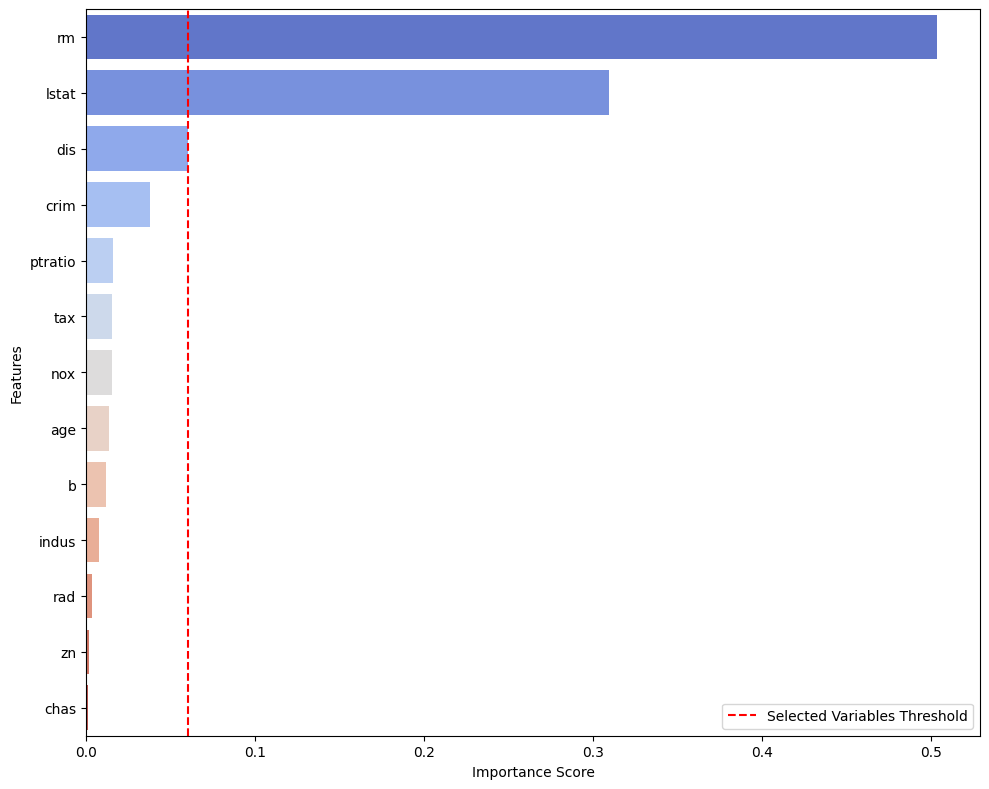

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
# 視覺化所有變數的重要性，與選擇的三個變數進行比較
plt.figure(figsize=(10, 8))
sns.barplot(
    x=feature_importances['Importance'],
    y=feature_importances['Feature'],
    orient='h',
    palette='coolwarm'
)
plt.axvline(x=feature_importances[feature_importances['Feature'] == 'dis']['Importance'].values[0], 
            color='red', linestyle='--', label='Selected Variables Threshold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()
